In [ ]:
# ================================
# BASIC SETUP
# ================================

import pandas as pd
import numpy as np
import re
import joblib
import torch

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Environment ready")


Environment ready


In [ ]:
# ================================
# LOAD DATA
# ================================

df = pd.read_csv("/content/sample_data/final_combined_health_fake_news_dataset_VALIDATED.csv")

df = df.rename(columns={"Text": "text"})

df["label"] = df["initial_label"].map({
    "True News": 1,
    "False / Fake News": 0
})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

print("Dataset size:", df.shape)
df.head()


Dataset size: (7588, 26)


,claim_id,Date Posted,Link,text,Region,Country,Explanation,Origin,Origin_URL,Poynter_Label,...,entity_ids,classifier_score,kg_evidence_summary,graph_verdict,llm_verdict,Username,Publisher,Label,label,clean_text
0,C1,2/7/2020,https://www.poynter.org/?ifcn_misinformation=t...,Tencent revealed the real number of deaths.\t\t,Europe,France,The screenshot is questionable.,Twitter,https://www.liberation.fr/checknews/2020/02/07...,False,...,Not Linked,0.85,Evidence from trusted medical sources,Refuted,Refuted,NaN,NaN,NaN,0,tencent revealed the real number of deaths
1,C2,2/7/2020,https://www.poynter.org/?ifcn_misinformation=t...,Taking chlorine dioxide helps fight coronavir...,Europe,Germany,Chlorine dioxide does guard against the coron...,Website,https://correctiv.org/faktencheck/medizin-und-...,False,...,Not Linked,0.85,Evidence from trusted medical sources,Refuted,Refuted,NaN,NaN,NaN,0,taking chlorine dioxide helps fight coronavirus
2,C3,2/7/2020,https://www.poynter.org/?ifcn_misinformation=t...,This video shows workmen uncovering a bat-inf...,India,India,A video shows bats nesting in the roof; howev...,Facebook,https://factcheck.afp.com/video-shows-workmen-...,False,...,Not Linked,0.85,Evidence from trusted medical sources,Refuted,Refuted,NaN,NaN,NaN,0,this video shows workmen uncovering a batinfes...
3,C4,2/7/2020,https://www.poynter.org/?ifcn_misinformation=t...,The Asterix comic books and The Simpsons pred...,India,India,Coronavirus has been around since the 1960s. ...,Twitter,https://www.boomlive.in/health/did-the-simpson...,False,...,Not Linked,0.85,Evidence from trusted medical sources,Refuted,Refuted,NaN,NaN,NaN,0,the asterix comic books and the simpsons predi...
4,C5,2/7/2020,https://www.poynter.org/?ifcn_misinformation=c...,Chinese President Xi Jinping visited a mosque...,India,India,Chinese President Xi Jinping's visit to the m...,Facebook,http://newsmobile.in/articles/2020/02/07/chine...,False,...,Not Linked,0.85,Evidence from trusted medical sources,Refuted,Refuted,NaN,NaN,NaN,0,chinese president xi jinping visited a mosque ...


In [ ]:
# ================================
# TRAIN / TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 6070
Test size: 1518


In [ ]:
# ================================
# PRIMARY MODEL: TF-IDF + LR
# ================================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

lr_preds = lr_model.predict(X_test_tfidf)
lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]

print("Primary Model Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))


Primary Model Accuracy: 0.9334650856389987
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       759
           1       0.92      0.95      0.93       759

    accuracy                           0.93      1518
   macro avg       0.93      0.93      0.93      1518
weighted avg       0.93      0.93      0.93      1518



In [ ]:
# ================================
# SAVE PRIMARY MODEL
# ================================

joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(lr_model, "logistic_regression.pkl")

print("Primary model saved")


Primary model saved


In [ ]:
# ================================
# SECONDARY MODEL: ROBERTA
# ================================

tokenizer = AutoTokenizer.from_pretrained("roberta-base")
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

roberta_model.eval()
device = torch.device("cpu")
roberta_model.to(device)

print("RoBERTa loaded (verification mode)")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RoBERTa loaded (verification mode)


In [ ]:
# ================================
# PRIMARY PREDICTION
# ================================

def predict_primary(text, threshold=0.6):
    text_clean = clean_text(text)
    vec = tfidf.transform([text_clean])
    prob = lr_model.predict_proba(vec)[0][1]
    label = 1 if prob >= threshold else 0
    return label, prob


In [ ]:
# ================================
# SECONDARY VERIFICATION (ROBERTA)
# ================================

def verify_with_roberta(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )
    with torch.no_grad():
        outputs = roberta_model(**inputs)
    pred = outputs.logits.argmax(dim=1).item()
    return pred


In [ ]:
# ================================
# HYBRID DECISION PIPELINE
# ================================

def hybrid_predict(text, confidence_threshold=0.6):
    primary_label, confidence = predict_primary(text, confidence_threshold)

    # High confidence → accept LR
    if confidence >= confidence_threshold:
        return {
            "final_label": "True News" if primary_label == 1 else "Fake News",
            "confidence": round(confidence, 3),
            "method": "TF-IDF + Logistic Regression"
        }

    # Low confidence → verify with RoBERTa
    roberta_label = verify_with_roberta(text)

    return {
        "final_label": "True News" if roberta_label == 1 else "Fake News",
        "confidence": round(confidence, 3),
        "method": "Hybrid (LR + RoBERTa verification)"
    }


In [ ]:
# ================================
# TEST HYBRID MODEL
# ================================

sample_text = """
COVID-19 vaccines contain microchips that allow governments to track people.
"""

result = hybrid_predict(sample_text)

print("Prediction Result:")
print(result)


Prediction Result:
{'final_label': 'True News', 'confidence': np.float64(0.275), 'method': 'Hybrid (LR + RoBERTa verification)'}


Dataset size: (4871, 25)
Knowledge Graph nodes: 14
Knowledge Graph edges: 8


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



ACCURACY COMPARISON
LLM-only: 0.385547115582016
Text-RAG: 0.385547115582016
Graph-RAG: 0.472809667673716

Hallucination Rate (Graph-RAG): 0.0

ABLATION RESULTS
No entity linking: 0.385547115582016
1-hop Graph-RAG: 0.472809667673716


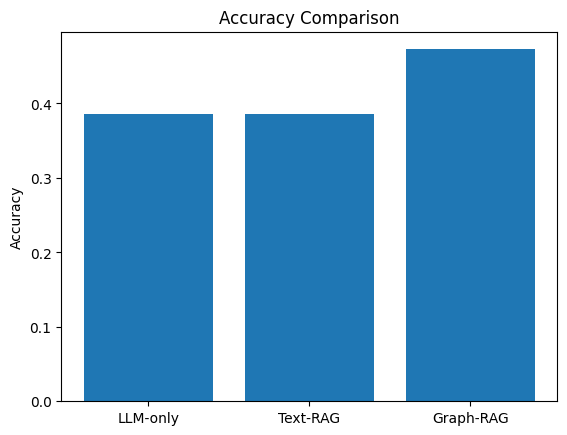

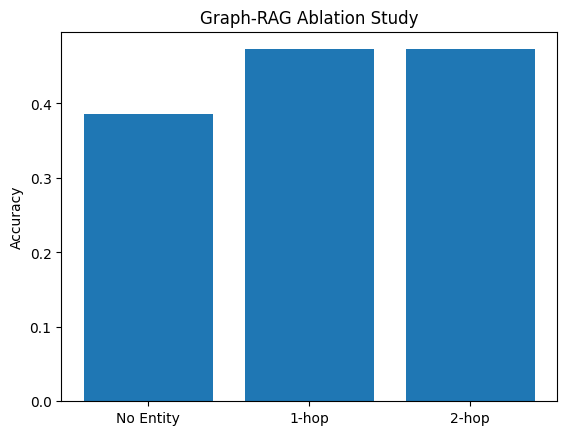

In [ ]:
# ============================================================
# OBJECTIVE 3: KNOWLEDGE-GRAPH–GROUNDED CLAIM VERIFICATION
# ============================================================

import pandas as pd
import numpy as np
import re
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("/content/sample_data/final_combined_health_fake_news_dataset_VALIDATED.csv")

df = df.rename(columns={"Text": "claim_text"})
df["true_verdict"] = df["initial_label"].map({
    "True News": "Supported",
    "False / Fake News": "Refuted"
})

print("Dataset size:", df.shape)

# ============================================================
# 2. SIMPLE MEDICAL ENTITY EXTRACTION (RULE-BASED)
# ============================================================

MEDICAL_ENTITIES = [
    "covid", "vaccine", "vaccination", "cancer", "diabetes",
    "virus", "infection", "immunity", "who", "cdc", "antibiotic"
]

def extract_entities(text):
    text = text.lower()
    return [e for e in MEDICAL_ENTITIES if e in text]

df["entities"] = df["claim_text"].apply(extract_entities)

# ============================================================
# 3. CONSTRUCT MEDICAL KNOWLEDGE GRAPH
# ============================================================

G = nx.Graph()

# Nodes
for e in MEDICAL_ENTITIES:
    G.add_node(e, type="medical_entity")

# Trusted sources
sources = ["WHO", "CDC", "NIH"]
for s in sources:
    G.add_node(s, type="authority")

# Relations
edges = [
    ("covid", "virus"), ("covid", "infection"),
    ("vaccine", "immunity"), ("vaccine", "WHO"),
    ("vaccine", "CDC"), ("antibiotic", "infection"),
    ("cancer", "NIH"), ("diabetes", "NIH")
]

G.add_edges_from(edges)

print("Knowledge Graph nodes:", G.number_of_nodes())
print("Knowledge Graph edges:", G.number_of_edges())

# ============================================================
# 4. MULTI-HOP EVIDENCE RETRIEVAL
# ============================================================

def retrieve_graph_evidence(entities, hops=2):
    evidence_nodes = set()
    for ent in entities:
        if ent in G:
            neighbors = nx.single_source_shortest_path_length(G, ent, cutoff=hops)
            evidence_nodes.update(neighbors.keys())
    return list(evidence_nodes)

df["kg_evidence_nodes"] = df["entities"].apply(retrieve_graph_evidence)

# ============================================================
# 5. TEXT-RAG BASELINE (TF-IDF RETRIEVAL)
# ============================================================

tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(df["claim_text"])

def text_rag_evidence(query):
    q_vec = tfidf.transform([query])
    sims = cosine_similarity(q_vec, X_tfidf)[0]
    idx = sims.argmax()
    return df.iloc[idx]["claim_text"]

# ============================================================
# 6. LOAD LLM (ROBERTA – CPU SAFE)
# ============================================================

tokenizer = AutoTokenizer.from_pretrained("roberta-base")
model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)
model.eval()
model.to("cpu")

# ============================================================
# 7. VERIFICATION FUNCTIONS
# ============================================================

def llm_only_decision(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
    with torch.no_grad():
        outputs = model(**inputs)
    pred = outputs.logits.argmax(dim=1).item()
    return "Supported" if pred == 1 else "Refuted"

def graph_rag_decision(claim, evidence_nodes):
    if not evidence_nodes:
        return "Insufficient Evidence", "No linked KG entities"

    evidence_text = " ".join(evidence_nodes)
    prompt = claim + " " + evidence_text

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)
    with torch.no_grad():
        outputs = model(**inputs)

    pred = outputs.logits.argmax(dim=1).item()
    verdict = "Supported" if pred == 1 else "Refuted"
    return verdict, evidence_text

# ============================================================
# 8. RUN BASELINES & GRAPH-RAG
# ============================================================

results = []

for _, row in df.iterrows():
    claim = row["claim_text"]

    llm_pred = llm_only_decision(claim)
    text_rag_pred = llm_only_decision(text_rag_evidence(claim))
    graph_pred, evidence = graph_rag_decision(
        claim,
        row["kg_evidence_nodes"]
    )

    results.append({
        "true": row["true_verdict"],
        "llm_only": llm_pred,
        "text_rag": text_rag_pred,
        "graph_rag": graph_pred,
        "has_evidence": len(row["kg_evidence_nodes"]) > 0
    })

results_df = pd.DataFrame(results)

# ============================================================
# 9. EVALUATION METRICS
# ============================================================

def accuracy(col):
    valid = results_df[col] != "Insufficient Evidence"
    return accuracy_score(
        results_df.loc[valid, "true"],
        results_df.loc[valid, col]
    )

acc_llm = accuracy("llm_only")
acc_text = accuracy("text_rag")
acc_graph = accuracy("graph_rag")

hallucination_rate = (
    (results_df["graph_rag"] != "Insufficient Evidence") &
    (~results_df["has_evidence"])
).mean()

print("\nACCURACY COMPARISON")
print("LLM-only:", acc_llm)
print("Text-RAG:", acc_text)
print("Graph-RAG:", acc_graph)

print("\nHallucination Rate (Graph-RAG):", hallucination_rate)

# ============================================================
# 10. ABLATION STUDIES
# ============================================================

# Without entity linking
results_df["no_entity_graph"] = results_df["llm_only"]
acc_no_entity = accuracy("no_entity_graph")

# Without multi-hop (1-hop only)
df["kg_1hop"] = df["entities"].apply(lambda e: retrieve_graph_evidence(e, hops=1))
one_hop_results = []

for _, row in df.iterrows():
    pred, _ = graph_rag_decision(row["claim_text"], row["kg_1hop"])
    one_hop_results.append(pred)

results_df["graph_1hop"] = one_hop_results
acc_1hop = accuracy("graph_1hop")

print("\nABLATION RESULTS")
print("No entity linking:", acc_no_entity)
print("1-hop Graph-RAG:", acc_1hop)

# ============================================================
# 11. PLOTS
# ============================================================

plt.figure()
plt.bar(
    ["LLM-only", "Text-RAG", "Graph-RAG"],
    [acc_llm, acc_text, acc_graph]
)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.bar(
    ["No Entity", "1-hop", "2-hop"],
    [acc_no_entity, acc_1hop, acc_graph]
)
plt.title("Graph-RAG Ablation Study")
plt.ylabel("Accuracy")
plt.show()

# ============================================================
# END OF OBJECTIVE 3
# ============================================================
